In [1]:
from vcf2pandas import vcf2pandas
import pandas as pd
import numpy as np

info_fields = {
    # ./-/+ --> 0:. 1:-/+
    'AG_Created': 'AGcheck_AG_Created',
    'AG_Lost': 'AGcheck_AG_Lost',
    'GT_Created': 'AGcheck_GT_Created',
    'GT_Lost': 'AGcheck_GT_Lost',
    # SNV/INDEL/INSDEL --> one hot encode
    'Variant_Type': 'AGcheck_Variant_Type',

    'Branchpointer_Prob': 'Branchpointer_Prob',
    'Branchpointer_U2_Binding_Energy': 'Branchpointer_U2_Binding_Energy',
    'Branchpointer_max_Prob': 'Branchpointer_max_Prob',
    'Branchpointer_max_U2_Binding_Energy': 'Branchpointer_max_U2_Binding_Energy',
    'Branchpointer_options': 'Branchpointer_options',

    'ESE_A1_Hazeem_alt': 'ESE_A1_Hazeem_alt',
    'ESE_A1_Hazeem_diff': 'ESE_A1_Hazeem_diff',
    'ESE_A1_Hazeem_july_alt': 'ESE_A1_Hazeem_july_alt',
    'ESE_A1_Hazeem_july_diff': 'ESE_A1_Hazeem_july_diff',
    'ESE_A1_neuBG_alt': 'ESE_A1_neuBG_alt',
    'ESE_A1_neuBG_diff': 'ESE_A1_neuBG_diff',
    'ESE_A1_winBG_alt': 'ESE_A1_winBG_alt',
    'ESE_A1_winBG_diff': 'ESE_A1_winBG_diff',
    'ESE_SRSF1_alt': 'ESE_SRSF1_alt',
    'ESE_SRSF1_diff': 'ESE_SRSF1_diff',
    'ESE_SRSF1_igM_alt': 'ESE_SRSF1_igM_alt',
    'ESE_SRSF1_igM_diff': 'ESE_SRSF1_igM_diff',
    'ESE_SRSF2_alt': 'ESE_SRSF2_alt',
    'ESE_SRSF2_diff': 'ESE_SRSF2_diff',
    'ESE_SRSF5_alt': 'ESE_SRSF5_alt',
    'ESE_SRSF5_diff': 'ESE_SRSF5_diff',
    'ESE_SRSF6_alt': 'ESE_SRSF6_alt',
    'ESE_SRSF6_diff': 'ESE_SRSF6_diff',

    'MMSplice_alt_acceptor': 'MMSplice_alt_acceptor',
    'MMSplice_alt_acceptor_intron': 'MMSplice_alt_acceptor_intron',
    'MMSplice_alt_donor': 'MMSplice_alt_donor',
    'MMSplice_alt_donor_intron': 'MMSplice_alt_donor_intron',
    'MMSplice_alt_exon': 'MMSplice_alt_exon',
    'MMSplice_delta_logit_PSI': 'MMSplice_delta_logit_PSI',
    'MMSplice_pathogenicity': 'MMSplice_pathogenicity',
    'MMSplice_ref_acceptor': 'MMSplice_ref_acceptor',
    'MMSplice_ref_acceptor_intron': 'MMSplice_ref_acceptor_intron',
    'MMSplice_ref_donor': 'MMSplice_ref_donor',
    'MMSplice_ref_donor_intron': 'MMSplice_ref_donor_intron',
    'MMSplice_ref_exon': 'MMSplice_ref_exon',

    'Pangolin_Gain': 'Pangolin_Gain',
    'Pangolin_Loss': 'Pangolin_Loss',

    'SPIP_Range_Max': 'SPIP_Range_Max',
    'SPIP_Range_Min': 'SPIP_Range_Min',
    'SPIP_Score': 'SPIP_Score',
    'SPiCE_Prob': 'SPIP_SPiCE_Prob',

    'DP_AG': 'SpliceAI_DP_AG',
    'DP_AL': 'SpliceAI_DP_AL',
    'DP_DG': 'SpliceAI_DP_DG',
    'DP_DL': 'SpliceAI_DP_DL',
    'DS_AG': 'SpliceAI_DS_AG',
    'DS_AG_ALT': 'SpliceAI_DS_AG_ALT',
    'DS_AL': 'SpliceAI_DS_AL',
    'DS_AL_ALT': 'SpliceAI_DS_AL_ALT',
    'DS_DG': 'SpliceAI_DS_DG',
    'DS_DG_ALT': 'SpliceAI_DS_DG_ALT',
    'DS_DL': 'SpliceAI_DS_DL',
    'DS_DL_ALT': 'SpliceAI_DS_DL_ALT',

    'AccGainP': 'Spliceogen_AccGainP',
    'AccLossP': 'Spliceogen_AccLossP',
    'DonGainP': 'Spliceogen_DonGainP',
    'DonLossP': 'Spliceogen_DonLossP',
    'ESEmaxAlt': 'Spliceogen_ESEmaxAlt',
    'ESEmaxRef': 'Spliceogen_ESEmaxRef',
    'ESSminAlt': 'Spliceogen_ESSminAlt',
    'ESSminRef': 'Spliceogen_ESSminRef',
    'mesAccAlt': 'Spliceogen_mesAccAlt',
    'mesAccRef': 'Spliceogen_mesAccRef',
    'mesDonAlt': 'Spliceogen_mesDonAlt',
    'mesDonRef': 'Spliceogen_mesDonRef',

    # U12/.      --> 0:. 1:U12
    'Intron_Type': 'U12_Intron_Type',
    # score/dots --> 0:. else score
    'U12_score': 'U12_score',
    # ./-/+      --> 0:. 1:-/+
    # 'U12_strand': 'U12_strand',

    # [('acceptor_canonical',) ('donor_region',) '.' ('donor_exonic',)
    #  ('acceptor_exonic',) ('donor_canonical',) ('branchpoint_region',)
    #  ('acceptor_region',)]
    'gene_regions': 'GENEINFO_gene_regions',

    ### Gencode file
    # intronic/exonic
    'Gene_Location': 'GENEINFO_is_intronic',
    # Exclude
    # 'gene': 'gene',

    # Exclude
    # [('protein_coding',) ('protein_coding', 'lncRNA')
    #  ('lncRNA', 'protein_coding')
    #  ('lncRNA', 'transcribed_unprocessed_pseudogene') ('lncRNA',) etc.
    # 'gene_type': 'gene_type',

    # [('-',) ('+',) ('+', '-') ('-', '+')]
    'strand': 'GENEINFO_strand',
    }

df = vcf2pandas("./FEB_25-bignewgpu__test.highquality.annotated.filtered.ensemblescored.otherannos.vcf",
    remove_empty_columns=True,
    info_fields=info_fields)

In [2]:
pd.set_option('display.max_columns', None)
df

,CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO:AGcheck_AG_Created,INFO:AGcheck_AG_Lost,INFO:AGcheck_GT_Created,INFO:AGcheck_GT_Lost,INFO:AGcheck_Variant_Type,INFO:Branchpointer_Prob,INFO:Branchpointer_U2_Binding_Energy,INFO:Branchpointer_max_Prob,INFO:Branchpointer_max_U2_Binding_Energy,INFO:Branchpointer_options,INFO:ESE_A1_Hazeem_alt,INFO:ESE_A1_Hazeem_diff,INFO:ESE_A1_Hazeem_july_alt,INFO:ESE_A1_Hazeem_july_diff,INFO:ESE_A1_neuBG_alt,INFO:ESE_A1_neuBG_diff,INFO:ESE_A1_winBG_alt,INFO:ESE_A1_winBG_diff,INFO:ESE_SRSF1_alt,INFO:ESE_SRSF1_diff,INFO:ESE_SRSF1_igM_alt,INFO:ESE_SRSF1_igM_diff,INFO:ESE_SRSF2_alt,INFO:ESE_SRSF2_diff,INFO:ESE_SRSF5_alt,INFO:ESE_SRSF5_diff,INFO:ESE_SRSF6_alt,INFO:ESE_SRSF6_diff,INFO:MMSplice_alt_acceptor,INFO:MMSplice_alt_acceptor_intron,INFO:MMSplice_alt_donor,INFO:MMSplice_alt_donor_intron,INFO:MMSplice_alt_exon,INFO:MMSplice_delta_logit_PSI,INFO:MMSplice_pathogenicity,INFO:MMSplice_ref_acceptor,INFO:MMSplice_ref_acceptor_intron,INFO:MMSplice_ref_donor,INFO:MMSplice_ref_donor_intron,INFO:MMSplice_ref_exon,INFO:Pangolin_Gain,INFO:Pangolin_Loss,INFO:SPIP_Range_Max,INFO:SPIP_Range_Min,INFO:SPIP_Score,INFO:SPIP_SPiCE_Prob,INFO:SpliceAI_DP_AG,INFO:SpliceAI_DP_AL,INFO:SpliceAI_DP_DG,INFO:SpliceAI_DP_DL,INFO:SpliceAI_DS_AG,INFO:SpliceAI_DS_AG_ALT,INFO:SpliceAI_DS_AL,INFO:SpliceAI_DS_AL_ALT,INFO:SpliceAI_DS_DG,INFO:SpliceAI_DS_DG_ALT,INFO:SpliceAI_DS_DL,INFO:SpliceAI_DS_DL_ALT,INFO:Spliceogen_AccGainP,INFO:Spliceogen_AccLossP,INFO:Spliceogen_DonGainP,INFO:Spliceogen_DonLossP,INFO:Spliceogen_ESEmaxAlt,INFO:Spliceogen_ESEmaxRef,INFO:Spliceogen_ESSminAlt,INFO:Spliceogen_ESSminRef,INFO:Spliceogen_mesAccAlt,INFO:Spliceogen_mesAccRef,INFO:Spliceogen_mesDonAlt,INFO:Spliceogen_mesDonRef,INFO:U12_Intron_Type,INFO:U12_score,INFO:GENEINFO_gene_regions,INFO:GENEINFO_is_intronic,INFO:GENEINFO_strand
0,chr1,945655,SVDBSplice,T,"(A,)",None,PASS,.,"(-,)",.,.,"(SNV,)",.,.,.,.,.,0,0,0,0,0,0,0,0,0,-2.099,1.935,-0.431,0,0,2.801,0.027,0,0,"(-0.2199999988079071,)","(-4.505000114440918,)","(2.7860000133514404,)","(-0.09700000286102295,)","(-1.555999994277954,)","(-2.8420000076293945,)","(1.0,)","(3.7100000381469727,)","(-4.505000114440918,)","(2.7860000133514404,)","(-0.09700000286102295,)","(-1.555999994277954,)","(0.8199999928474426,)","(-0.8600000143051147,)","(99.95999908447266,)","(91.47000122070312,)","(98.41000366210938,)","(0.9999600052833557,)","(-9.0,)","(-2.0,)","(-332.0,)","(373.0,)","(0.9599999785423279,)","(0.9599999785423279,)","(0.9200000166893005,)","(0.07999999821186066,)","(0.019999999552965164,)","(0.07999999821186066,)","(0.019999999552965164,)","(0.41999998688697815,)",0.98,0.98,.,.,0.484,.,-0.21,-0.365,3.1,8.85,.,.,.,.,"(acceptor_canonical,)","(intronic,)","(-,)"
1,chr1,951995,SVDBSplice,C,"(T,)",None,PASS,.,"(-,)",.,"(-,)","(SNV,)",.,.,.,.,.,0,0,0,0,0,0,0,0,0,0,0,0,3.175,3.175,0,0,0,0,"(3.6059999465942383,)","(-2.9630000591278076,)","(-2.0169999599456787,)","(0.32100000977516174,)","(-3.947999954223633,)","(-4.590000152587891,)","(1.0,)","(3.6059999465942383,)","(-2.9630000591278076,)","(4.1020002365112305,)","(0.32100000977516174,)","(-3.947999954223633,)","(0.1599999964237213,)","(-0.7099999785423279,)","(99.95999908447266,)","(91.47000122070312,)","(98.41000366210938,)","(0.9996600151062012,)","(205.0,)","(144.0,)","(116.0,)","(5.0,)","(0.009999999776482582,)","(0.009999999776482582,)","(0.5799999833106995,)","(0.41999998688697815,)","(0.10999999940395355,)","(0.10999999940395355,)","(0.7599999904632568,)","(0.23999999463558197,)",.,.,0.00,0.99,0.199,0.132,-0.157,-0.374,1.76,0.71,1.48,9.1,.,.,"(donor_region,)","(intronic,)","(-,)"
2,chr1,963993,SVDBSplice,C,"(T,)",None,PASS,.,.,"(+,)",.,"(SNV,)",.,.,.,.,.,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3.533,0.357,2.821,2.821,"(1.5019999742507935,)","(-4.7779998779296875,)","(1.2059999704360962,)","(-0.25099998712539673,)","(-2.183000087738037,)","(-0.19900000095367432,)","(0.5979999899864197,)","(1.5019999742507935,)","(-4.7779998779296875,)","(1.2059999704360962,)","(-0.250999987

In [3]:
for col in df.columns:
    if col == "REF" or col == "ALT":
        continue
    if not pd.api.types.is_numeric_dtype(df[col]):
        print(f"Column: {col}")
        print("Unique values:", df[col].unique())
        print()

Column: CHROM
Unique values: ['chr1' 'chr2' 'chr3' 'chr4' 'chr5' 'chr6' 'chr7' 'chr8' 'chr9' 'chr10'
 'chr11' 'chr12' 'chr13' 'chr14' 'chr15' 'chr16' 'chr17' 'chr18' 'chr19'
 'chr20' 'chr21' 'chr22' 'chrX' 'chrY']

Column: ID
Unique values: ['SVDBSplice' 'SVDBNormal' 'SVDBConflicting']

Column: QUAL
Unique values: [None]

Column: FILTER
Unique values: ['PASS']

Column: INFO:AGcheck_AG_Created
Unique values: ['.' ('-',) ('+',)]

Column: INFO:AGcheck_AG_Lost
Unique values: [('-',) '.' ('+',)]

Column: INFO:AGcheck_GT_Created
Unique values: ['.' ('+',) ('-',)]

Column: INFO:AGcheck_GT_Lost
Unique values: ['.' ('-',) ('+',)]

Column: INFO:AGcheck_Variant_Type
Unique values: [('SNV',) ('INDEL',) ('INSDEL',)]

Column: INFO:Branchpointer_Prob
Unique values: ['.' 1.399999976158142 2.9000000953674316 3.299999952316284
 1.600000023841858 2.700000047683716 1.0 0.30000001192092896
 0.699999988079071 0.10000000149011612 7.0 5.099999904632568
 1.100000023841858 5.800000190734863 0.800000011920929 4.

In [4]:
df[df['ID'] == 'SVDBConflicting']

,CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO:AGcheck_AG_Created,INFO:AGcheck_AG_Lost,INFO:AGcheck_GT_Created,INFO:AGcheck_GT_Lost,INFO:AGcheck_Variant_Type,INFO:Branchpointer_Prob,INFO:Branchpointer_U2_Binding_Energy,INFO:Branchpointer_max_Prob,INFO:Branchpointer_max_U2_Binding_Energy,INFO:Branchpointer_options,INFO:ESE_A1_Hazeem_alt,INFO:ESE_A1_Hazeem_diff,INFO:ESE_A1_Hazeem_july_alt,INFO:ESE_A1_Hazeem_july_diff,INFO:ESE_A1_neuBG_alt,INFO:ESE_A1_neuBG_diff,INFO:ESE_A1_winBG_alt,INFO:ESE_A1_winBG_diff,INFO:ESE_SRSF1_alt,INFO:ESE_SRSF1_diff,INFO:ESE_SRSF1_igM_alt,INFO:ESE_SRSF1_igM_diff,INFO:ESE_SRSF2_alt,INFO:ESE_SRSF2_diff,INFO:ESE_SRSF5_alt,INFO:ESE_SRSF5_diff,INFO:ESE_SRSF6_alt,INFO:ESE_SRSF6_diff,INFO:MMSplice_alt_acceptor,INFO:MMSplice_alt_acceptor_intron,INFO:MMSplice_alt_donor,INFO:MMSplice_alt_donor_intron,INFO:MMSplice_alt_exon,INFO:MMSplice_delta_logit_PSI,INFO:MMSplice_pathogenicity,INFO:MMSplice_ref_acceptor,INFO:MMSplice_ref_acceptor_intron,INFO:MMSplice_ref_donor,INFO:MMSplice_ref_donor_intron,INFO:MMSplice_ref_exon,INFO:Pangolin_Gain,INFO:Pangolin_Loss,INFO:SPIP_Range_Max,INFO:SPIP_Range_Min,INFO:SPIP_Score,INFO:SPIP_SPiCE_Prob,INFO:SpliceAI_DP_AG,INFO:SpliceAI_DP_AL,INFO:SpliceAI_DP_DG,INFO:SpliceAI_DP_DL,INFO:SpliceAI_DS_AG,INFO:SpliceAI_DS_AG_ALT,INFO:SpliceAI_DS_AL,INFO:SpliceAI_DS_AL_ALT,INFO:SpliceAI_DS_DG,INFO:SpliceAI_DS_DG_ALT,INFO:SpliceAI_DS_DL,INFO:SpliceAI_DS_DL_ALT,INFO:Spliceogen_AccGainP,INFO:Spliceogen_AccLossP,INFO:Spliceogen_DonGainP,INFO:Spliceogen_DonLossP,INFO:Spliceogen_ESEmaxAlt,INFO:Spliceogen_ESEmaxRef,INFO:Spliceogen_ESSminAlt,INFO:Spliceogen_ESSminRef,INFO:Spliceogen_mesAccAlt,INFO:Spliceogen_mesAccRef,INFO:Spliceogen_mesDonAlt,INFO:Spliceogen_mesDonRef,INFO:U12_Intron_Type,INFO:U12_score,INFO:GENEINFO_gene_regions,INFO:GENEINFO_is_intronic,INFO:GENEINFO_strand
58,chr1,3468922,SVDBConflicting,C,"(T,)",None,PASS,.,.,"(+,)",.,"(SNV,)",.,.,.,.,.,0,0,0,0,0,0,0,0,0,-3.168,0,0,0,0,0,0,0,-3.07,"(3.946000099182129,)","(-4.436999797821045,)","(4.23199987411499,)","(-0.12099999934434891,)","(-2.4809999465942383,)","(-0.3630000054836273,)","(0.15000000596046448,)","(3.946000099182129,)","(-4.436999797821045,)","(4.23199987411499,)","(-0.12099999934434891,)","(-2.246000051498413,)","(0.0,)","(-0.07999999821186066,)","(44.099998474121094,)","(28.110000610351562,)","(35.810001373291016,)","(0.0,)","(14.0,)","(-42.0,)","(-43.0,)","(14.0,)","(0.0,)","(0.0,)","(0.15000000596046448,)","(0.75,)","(0.0,)","(0.0,)","(0.10000000149011612,)","(0.8199999928474426,)",0.01,.,0.02,.,0.587,0.461,.,.,-12.88,-14.05,-18.41,-26.16,.,.,.,"(exonic,)","(+,)"
125,chr1,10368558,SVDBConflicting,T,"(A,)",None,PASS,.,.,.,.,"(SNV,)",.,.,.,.,.,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"(2.7260000705718994,)","(-3.428999900817871,)","(3.4670000076293945,)","(0.460999995470047,)","(-3.299999952316284,)","(-0.004999999888241291,)","(0.28999999165534973,)","(2.7260000705718994,)","(-3.428999900817871,)","(3.4670000076293945,)","(0.46399998664855957,)","(-3.299999952316284,)","(0.0,)","(-0.009999999776482582,)","(2.0799999237060547,)","(0.15000000596046448,)","(0.7200000286102295,)","(0.0,)","(-647.0,)","(151.0,)","(-162.0,)","(-20.0,)","(0.0,)","(0.1899999976158142,)","(0.0,)","(0.10000000149011612,)","(0.0,)","(0.009999999776482582,)","(0.0,)","(1.0,)",0.57,.,0.59,.,.,.,-0.725,-0.599,4.72,5.12,0.41,-0.86,.,.,.,"(intronic,)","(+,)"
1526,chr1,155675041,SVDBConflicting,T,"(C,)",None,PASS,"(-,)",.,"(-,)",.,"(SNV,)",.,.,.,.,.,0,0,0,0,0,0,0,0,2.292,2.292,0,0,2.968,2.968,3.206,-0.155,0,0,"(4.038000106811523,)","(-3.0950000286102295,)","(2.247999906539917,)","(0.5230000019073486,)","(-4.017000198364258,)","(-0.12700000405311584,)","(0.3869999945163727,)","(4.038000106811523,)","(-3.0950000286102295,)","(2.247999906539917,)","(0.5230000019073486,)","(-3.934999942779541,)","(0.0,)","(-0.019999999552965164,)","(34.34000015258789,)","(19.829999923706055,)","(26.6200008392334,)","(0.0,)","(-1.0,)","(-223.0,)","(-49.0,)","(-31.0,)","(0.0,)","(0.0,)","(0.

In [5]:
ese        = [col for col in df.columns if col.startswith('INFO:ESE_')]
mmsplice   = [col for col in df.columns if col.startswith('INFO:MMSplice_')]
pangolin   = [col for col in df.columns if col.startswith('INFO:Pangolin_')]
spip       = [col for col in df.columns if col.startswith('INFO:SPIP_')]
spliceai   = [col for col in df.columns if col.startswith('INFO:SpliceAI_DS')]
spliceogen = [col for col in df.columns if col.startswith('INFO:Spliceogen_')]

ensemble_scores = [ese, mmsplice, pangolin, spliceai, spliceogen, spip]

for l in ensemble_scores:
    print(len(l), l)


18 ['INFO:ESE_A1_Hazeem_alt', 'INFO:ESE_A1_Hazeem_diff', 'INFO:ESE_A1_Hazeem_july_alt', 'INFO:ESE_A1_Hazeem_july_diff', 'INFO:ESE_A1_neuBG_alt', 'INFO:ESE_A1_neuBG_diff', 'INFO:ESE_A1_winBG_alt', 'INFO:ESE_A1_winBG_diff', 'INFO:ESE_SRSF1_alt', 'INFO:ESE_SRSF1_diff', 'INFO:ESE_SRSF1_igM_alt', 'INFO:ESE_SRSF1_igM_diff', 'INFO:ESE_SRSF2_alt', 'INFO:ESE_SRSF2_diff', 'INFO:ESE_SRSF5_alt', 'INFO:ESE_SRSF5_diff', 'INFO:ESE_SRSF6_alt', 'INFO:ESE_SRSF6_diff']
12 ['INFO:MMSplice_alt_acceptor', 'INFO:MMSplice_alt_acceptor_intron', 'INFO:MMSplice_alt_donor', 'INFO:MMSplice_alt_donor_intron', 'INFO:MMSplice_alt_exon', 'INFO:MMSplice_delta_logit_PSI', 'INFO:MMSplice_pathogenicity', 'INFO:MMSplice_ref_acceptor', 'INFO:MMSplice_ref_acceptor_intron', 'INFO:MMSplice_ref_donor', 'INFO:MMSplice_ref_donor_intron', 'INFO:MMSplice_ref_exon']
2 ['INFO:Pangolin_Gain', 'INFO:Pangolin_Loss']
8 ['INFO:SpliceAI_DS_AG', 'INFO:SpliceAI_DS_AG_ALT', 'INFO:SpliceAI_DS_AL', 'INFO:SpliceAI_DS_AL_ALT', 'INFO:SpliceAI_DS_D

In [6]:
def assert_and_convert_single_float_tuples_allow_dot(df: pd.DataFrame, *,
                                                     dots_largeminus: list[str],
                                                     dots_zeros: list[str],
                                                     nans_zeros: list[str],
                                                     nans_large_minus: list[str]) -> pd.DataFrame:
    """
    For each column in df:
      - If the column contains any tuples, assert that every tuple is either:
          * length-1 and contains a float, or
          * is None, or
          * equals the string "."
      - Convert such valid single-float tuples to the float value.
      - Leave the "." string as-is instead of trying to convert it to float.
    Returns a copy of df with the converted columns (dtype may remain 'object' 
    if "." strings are present).
    """
    df = df.copy()
    
    for col in df.columns:
        # Check if this column contains *any* tuples
        has_tuple = df[col].apply(lambda x: isinstance(x, tuple)).any()
        
        if has_tuple:
            # Define a helper to check if each value is valid
            def is_valid_tuple(x):
                # Valid if it's None, or the special ".", or a single-float tuple
                if x is None or x == "." or not isinstance(x, tuple):
                    return True
                if (x[0] is None):
                    print(col, x[0])
                return (len(x) == 1 and (isinstance(x[0], float) or x[0] is None))
            
            # If any row fails the validity check, raise an error
            valid_series = df[col].apply(is_valid_tuple)
            if not valid_series.all():
                # Extract offending values
                offending_values = df[col][~valid_series].unique()
                raise ValueError(
                    f"Column '{col}' contains invalid tuple values: {offending_values}"
                )
            
        # Convert single-float tuples to that float
        def convert_tuple_to_float(x):
            if isinstance(x, tuple):
                return sanitise(x[0])  # we've already asserted it's length-1 float
            return sanitise(x)
        
        def sanitise(x):
            if not (str(x) in ["", ".", "NaN", "nan", "None"]):
                return x
            # because spliceai can't do multinucleotide to multinucleotide variants.
            if any(col.startswith(x) for x in dots_largeminus) and (str(x) == "." or str(x) == ""):
                return -99999
            if any(col.startswith(x) for x in dots_zeros) and (str(x) == "." or str(x) == ""):
                return 0
            if any(col.startswith(x) for x in nans_zeros) and str(x) in ["NaN", "nan", "None"]:
                return 0
            if any(col.startswith(x) for x in nans_large_minus) and str(x) in ["NaN", "nan", "None"]:
                return -99999
            return x
        
        df[col] = df[col].apply(convert_tuple_to_float)
            
            # If you wanted to convert *everything* that *can* be a float (except "."),
            # you could do something like this:
            #
            #     def try_float(x):
            #         if x == "." or x is None:
            #             return x  # leave "." or None as-is
            #         try:
            #             return float(x)
            #         except (ValueError, TypeError):
            #             return x
            #
            #     df[col] = df[col].apply(try_float)
            #
            # However, if you only need to convert the tuples (and trust the rest 
            # are already correct), the above tuple conversion alone might suffice.
    # if dots_zeros:
    #     df = df.astype(str).replace(to_replace=["."], value=("0"))
    
    # if nans_zeros:
    #     df = df.astype(str).replace(to_replace=["NaN", "nan", "None"], value=("0"))
    
    # df = df.astype(str).replace(to_replace=["True"], value=("1"))
    # df = df.astype(str).replace(to_replace=["False"], value=("0"))
    
    return df

## Cleaning

df_rem = df[df['ID'] != 'SVDBConflicting']
df_rem = pd.get_dummies(df_rem, columns=['ID'])
df_rem

for col in [col for col in df.columns if col.startswith('INFO:AGcheck_')]:
    if not col.endswith('Created') and not col.endswith('Lost'):
        continue
    # Convert AGcheck_lost/created to 0 if dot, and 1 if minus OR plus strand
    df_rem[col] = (df_rem[col] != '.')

df_rem = pd.get_dummies(df_rem, columns=['INFO:AGcheck_Variant_Type'])

# Convert U12_Intron_Type to U12_Intron_Type ("U12" -> 1, otherwise 0)
df_rem['INFO:U12_Intron_Type'] = (df_rem['INFO:U12_Intron_Type'] == 'U12')
# Convert U12_strand to 0 if dot, and 1 if minus OR plus
# df_rem['INFO:U12_strand'] = (df_rem['INFO:U12_strand'] != '.').astype(int)


df_rem = pd.get_dummies(df_rem, columns=['INFO:GENEINFO_gene_regions'])

df_rem['INFO:GENEINFO_is_intronic'] = (df_rem['INFO:GENEINFO_is_intronic'] == ('intronic',))

df_rem['INFO:GENEINFO_strand_minus'] = df_rem['INFO:GENEINFO_strand'].apply(lambda x: '-' in x)
df_rem['INFO:GENEINFO_strand_plus'] = df_rem['INFO:GENEINFO_strand'].apply(lambda x: '+' in x)
df_rem = df_rem.drop(columns=['INFO:GENEINFO_strand'])

agcheck    = [col for col in df_rem.columns if col.startswith('INFO:AGcheck_')]
bpter      = [col for col in df_rem.columns if col.startswith('INFO:Branchpointer_')]
u12        = [col for col in df_rem.columns if col.startswith('INFO:U12_')]
geneinfo   = [col for col in df_rem.columns if col.startswith('INFO:GENEINFO_')]
info       = [agcheck, bpter, u12, geneinfo]


In [7]:
for col in df_rem.columns:
    if col == "REF" or col == "ALT":
        continue
    print(f"Column: {col}")
    print("Unique values:", df_rem[col].unique())
    if col.startswith('INFO:MMSplice'):
        vals = [float(tup[0]) if tup[0] != "." else 0 for tup in df_rem[col]]
        min_val = min(vals)
        max_val = max(vals)
        median_val = np.median(vals)
        print(f"Min: {min_val}, Max: {max_val}, Median: {median_val}")
    print()

Column: CHROM
Unique values: ['chr1' 'chr2' 'chr3' 'chr4' 'chr5' 'chr6' 'chr7' 'chr8' 'chr9' 'chr10'
 'chr11' 'chr12' 'chr13' 'chr14' 'chr15' 'chr16' 'chr17' 'chr18' 'chr19'
 'chr20' 'chr21' 'chr22' 'chrX' 'chrY']

Column: POS
Unique values: [  945655   951995   963993 ... 19743144 19743165 19743205]

Column: QUAL
Unique values: [None]

Column: FILTER
Unique values: ['PASS']

Column: INFO:AGcheck_AG_Created
Unique values: [False  True]

Column: INFO:AGcheck_AG_Lost
Unique values: [ True False]

Column: INFO:AGcheck_GT_Created
Unique values: [False  True]

Column: INFO:AGcheck_GT_Lost
Unique values: [False  True]

Column: INFO:Branchpointer_Prob
Unique values: ['.' 1.399999976158142 2.9000000953674316 3.299999952316284
 1.600000023841858 2.700000047683716 1.0 0.30000001192092896
 0.699999988079071 0.10000000149011612 7.0 5.099999904632568
 1.100000023841858 5.800000190734863 0.800000011920929 4.699999809265137
 1.2999999523162842 0.5 4.0 8.100000381469727 0.4000000059604645
 3.400000095

In [9]:
from itertools import chain
scores = list(chain.from_iterable(ensemble_scores))
use_info = True

scores = scores.copy()
if use_info:
    scores.extend(list(chain.from_iterable(info)))
columns = scores + ['ID_SVDBSplice']
print(f"{len(columns)=} {columns=}")
features = assert_and_convert_single_float_tuples_allow_dot(df_rem[columns],
                                                            dots_largeminus=['INFO:SpliceAI_DP',
                                                                             'INFO:SPIP',],
                                                            dots_zeros=['INFO:U12',
                                                                        'INFO:Branchpointer',
                                                                        'INFO:SpliceAI_DS',
                                                                        'INFO:Spliceogen',
                                                                        'INFO:MMSplice',
                                                                        'INFO:Pangolin'],
                                                            nans_zeros=[],
                                                            nans_large_minus=['INFO:SPIP'])
print("before:", len(features))

bad_features = features[features.isin(["."]).any(axis=1)]
features = features[~features.isin(["."]).any(axis=1)]
print("after:", len(features))

print("Removed bad features:")
print(bad_features.to_string())

features = features.astype(float).round(3)
features

len(columns)=82 columns=['INFO:ESE_A1_Hazeem_alt', 'INFO:ESE_A1_Hazeem_diff', 'INFO:ESE_A1_Hazeem_july_alt', 'INFO:ESE_A1_Hazeem_july_diff', 'INFO:ESE_A1_neuBG_alt', 'INFO:ESE_A1_neuBG_diff', 'INFO:ESE_A1_winBG_alt', 'INFO:ESE_A1_winBG_diff', 'INFO:ESE_SRSF1_alt', 'INFO:ESE_SRSF1_diff', 'INFO:ESE_SRSF1_igM_alt', 'INFO:ESE_SRSF1_igM_diff', 'INFO:ESE_SRSF2_alt', 'INFO:ESE_SRSF2_diff', 'INFO:ESE_SRSF5_alt', 'INFO:ESE_SRSF5_diff', 'INFO:ESE_SRSF6_alt', 'INFO:ESE_SRSF6_diff', 'INFO:MMSplice_alt_acceptor', 'INFO:MMSplice_alt_acceptor_intron', 'INFO:MMSplice_alt_donor', 'INFO:MMSplice_alt_donor_intron', 'INFO:MMSplice_alt_exon', 'INFO:MMSplice_delta_logit_PSI', 'INFO:MMSplice_pathogenicity', 'INFO:MMSplice_ref_acceptor', 'INFO:MMSplice_ref_acceptor_intron', 'INFO:MMSplice_ref_donor', 'INFO:MMSplice_ref_donor_intron', 'INFO:MMSplice_ref_exon', 'INFO:Pangolin_Gain', 'INFO:Pangolin_Loss', 'INFO:SpliceAI_DS_AG', 'INFO:SpliceAI_DS_AG_ALT', 'INFO:SpliceAI_DS_AL', 'INFO:SpliceAI_DS_AL_ALT', 'INFO:Sp

,INFO:ESE_A1_Hazeem_alt,INFO:ESE_A1_Hazeem_diff,INFO:ESE_A1_Hazeem_july_alt,INFO:ESE_A1_Hazeem_july_diff,INFO:ESE_A1_neuBG_alt,INFO:ESE_A1_neuBG_diff,INFO:ESE_A1_winBG_alt,INFO:ESE_A1_winBG_diff,INFO:ESE_SRSF1_alt,INFO:ESE_SRSF1_diff,INFO:ESE_SRSF1_igM_alt,INFO:ESE_SRSF1_igM_diff,INFO:ESE_SRSF2_alt,INFO:ESE_SRSF2_diff,INFO:ESE_SRSF5_alt,INFO:ESE_SRSF5_diff,INFO:ESE_SRSF6_alt,INFO:ESE_SRSF6_diff,INFO:MMSplice_alt_acceptor,INFO:MMSplice_alt_acceptor_intron,INFO:MMSplice_alt_donor,INFO:MMSplice_alt_donor_intron,INFO:MMSplice_alt_exon,INFO:MMSplice_delta_logit_PSI,INFO:MMSplice_pathogenicity,INFO:MMSplice_ref_acceptor,INFO:MMSplice_ref_acceptor_intron,INFO:MMSplice_ref_donor,INFO:MMSplice_ref_donor_intron,INFO:MMSplice_ref_exon,INFO:Pangolin_Gain,INFO:Pangolin_Loss,INFO:SpliceAI_DS_AG,INFO:SpliceAI_DS_AG_ALT,INFO:SpliceAI_DS_AL,INFO:SpliceAI_DS_AL_ALT,INFO:SpliceAI_DS_DG,INFO:SpliceAI_DS_DG_ALT,INFO:SpliceAI_DS_DL,INFO:SpliceAI_DS_DL_ALT,INFO:Spliceogen_AccGainP,INFO:Spliceogen_AccLossP,INFO:Spliceogen_DonGainP,INFO:Spliceogen_DonLossP,INFO:Spliceogen_ESEmaxAlt,INFO:Spliceogen_ESEmaxRef,INFO:Spliceogen_ESSminAlt,INFO:Spliceogen_ESSminRef,INFO:Spliceogen_mesAccAlt,INFO:Spliceogen_mesAccRef,INFO:Spliceogen_mesDonAlt,INFO:Spliceogen_mesDonRef,INFO:SPIP_Range_Max,INFO:SPIP_Range_Min,INFO:SPIP_Score,INFO:SPIP_SPiCE_Prob,INFO:AGcheck_AG_Created,INFO:AGcheck_AG_Lost,INFO:AGcheck_GT_Created,INFO:AGcheck_GT_Lost,"INFO:AGcheck_Variant_Type_('INDEL',)","INFO:AGcheck_Variant_Type_('INSDEL',)","INFO:AGcheck_Variant_Type_('SNV',)",INFO:Branchpointer_Prob,INFO:Branchpointer_U2_Binding_Energy,INFO:Branchpointer_max_Prob,INFO:Branchpointer_max_U2_Binding_Energy,INFO:Branchpointer_options,INFO:U12_Intron_Type,INFO:U12_score,INFO:GENEINFO_is_intronic,INFO:GENEINFO_gene_regions_.,"INFO:GENEINFO_gene_regions_('acceptor_canonical',)","INFO:GENEINFO_gene_regions_('acceptor_exonic',)","INFO:GENEINFO_gene_regions_('acceptor_region',)","INFO:GENEINFO_gene_regions_('branchpoint_region',)","INFO:GENEINFO_gene_regions_('donor_canonical',)","INFO:GENEINFO_gene_regions_('donor_exonic',)","INFO:GENEINFO_gene_regions_('donor_region',)",INFO:GENEINFO_strand_minus,INFO:GENEINFO_strand_plus,ID_SVDBSplice
0,0.000,0.000,0.0,0.0,0.0,0.000,0.0,0.000,0.000,-2.099,1.935,-0.431,0.000,0.000,2.801,0.027,0.000,0.000,-0.220,-4.505,2.786,-0.097,-1.556,-2.842,1.000,3.710,-4.505,2.786,-0.097,-1.556,0.82,-0.86,0.96,0.96,0.92,0.08,0.02,0.08,0.02,0.42,0.98,0.98,0.00,0.00,0.484,0.000,-0.210,-0.365,3.10,8.85,0.00,0.00,99.96,91.47,98.41,1.000,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1,0.000,0.000,0.0,0.0,0.0,0.000,0.0,0.000,0.000,0.000,0.000,0.000,3.175,3.175,0.000,0.000,0.000,0.000,3.606,-2.963,-2.017,0.321,-3.948,-4.590,1.000,3.606,-2.963,4.102,0.321,-3.948,0.16,-0.71,0.01,0.01,0.58,0.42,0.11,0.11,0.76,0.24,0.00,0.00,0.00,0.99,0.199,0.132,-0.157,-0.374,1.76,0.71,1.48,9.10,99.96,91.47,98.41,1.000,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0
2,0.000,0.000,0.0,0.0,0.0,0.000,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,3.533,0.357,2.821,2.821,1.502,-4.778,1.206,-0.251,-2.183,-0.199,0.598,1.502,-4.778,1.206,-0.251,-2.053,0.87,-0.69,0.12,0.42,0.00,0.30,0.96,0.99,0.67,0.27,0.00,0.00,0.93,0.00,0.171,0.165,-0.073,-0.081,-17.24,-14.95,5.84,-1.91,44.10,28.11,35.81,0.000,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
3,0.000,0.000,0.0,0.0,0.0,0.000,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,2.404,-4.712,0.657,0.097,-2.713,-2.868,1.000,2.404,-4.712,4.482,0.097,-2.713,0.04,-0.70,0.00,0.01,0.33,0.31,0.25,0.26,0.35,0.65,0.00,0.00,0.00,0.91,0.480,0.535,-0.359,-0.416,-8.31,-8.60,2.56,6.64,99.96,91.47,98.41,0.996,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0
4,0.000,0.000,0.0,0.0,0.0,-3.551,0.0,-3.078,2.598,2.598,0.000,0.000,0.000,0.000,0.000

In [12]:
print(len(features.columns))
for col in features.columns:
    print(f"{col}")

82
INFO:ESE_A1_Hazeem_alt
INFO:ESE_A1_Hazeem_diff
INFO:ESE_A1_Hazeem_july_alt
INFO:ESE_A1_Hazeem_july_diff
INFO:ESE_A1_neuBG_alt
INFO:ESE_A1_neuBG_diff
INFO:ESE_A1_winBG_alt
INFO:ESE_A1_winBG_diff
INFO:ESE_SRSF1_alt
INFO:ESE_SRSF1_diff
INFO:ESE_SRSF1_igM_alt
INFO:ESE_SRSF1_igM_diff
INFO:ESE_SRSF2_alt
INFO:ESE_SRSF2_diff
INFO:ESE_SRSF5_alt
INFO:ESE_SRSF5_diff
INFO:ESE_SRSF6_alt
INFO:ESE_SRSF6_diff
INFO:MMSplice_alt_acceptor
INFO:MMSplice_alt_acceptor_intron
INFO:MMSplice_alt_donor
INFO:MMSplice_alt_donor_intron
INFO:MMSplice_alt_exon
INFO:MMSplice_delta_logit_PSI
INFO:MMSplice_pathogenicity
INFO:MMSplice_ref_acceptor
INFO:MMSplice_ref_acceptor_intron
INFO:MMSplice_ref_donor
INFO:MMSplice_ref_donor_intron
INFO:MMSplice_ref_exon
INFO:Pangolin_Gain
INFO:Pangolin_Loss
INFO:SpliceAI_DS_AG
INFO:SpliceAI_DS_AG_ALT
INFO:SpliceAI_DS_AL
INFO:SpliceAI_DS_AL_ALT
INFO:SpliceAI_DS_DG
INFO:SpliceAI_DS_DG_ALT
INFO:SpliceAI_DS_DL
INFO:SpliceAI_DS_DL_ALT
INFO:Spliceogen_AccGainP
INFO:Spliceogen_AccLossP


In [10]:
target = features['ID_SVDBSplice']
features = features.drop(columns=['ID_SVDBSplice'])

ones = (target == 1).sum()
zeros = (target == 0).sum()

print(f'{target}, {ones=}, {zeros=}')

0        1.0
1        1.0
2        1.0
3        1.0
4        1.0
        ... 
25109    0.0
25110    1.0
25111    0.0
25112    0.0
25113    0.0
Name: ID_SVDBSplice, Length: 24725, dtype: float64, ones=13396, zeros=11329


In [11]:
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV

from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.svm import SVC

from sklearn.metrics import average_precision_score, precision_recall_curve, PrecisionRecallDisplay, roc_auc_score
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error, f1_score
import matplotlib.pyplot as plt

X_train_, X_test, y_train_, y_test = train_test_split(features, target, test_size=0.20, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_, y_train_, test_size=0.20, random_state=42)
print(f"Train: {len(X_train)}\nValidation: {len(X_val)}\nTest: {len(X_test)}")

Train: 15824
Validation: 3956
Test: 4945


,INFO:ESE_A1_Hazeem_alt,INFO:ESE_A1_Hazeem_diff,INFO:ESE_A1_Hazeem_july_alt,INFO:ESE_A1_Hazeem_july_diff,INFO:ESE_A1_neuBG_alt,INFO:ESE_A1_neuBG_diff,INFO:ESE_A1_winBG_alt,INFO:ESE_A1_winBG_diff,INFO:ESE_SRSF1_alt,INFO:ESE_SRSF1_diff,INFO:ESE_SRSF1_igM_alt,INFO:ESE_SRSF1_igM_diff,INFO:ESE_SRSF2_alt,INFO:ESE_SRSF2_diff,INFO:ESE_SRSF5_alt,INFO:ESE_SRSF5_diff,INFO:ESE_SRSF6_alt,INFO:ESE_SRSF6_diff,INFO:MMSplice_alt_acceptor,INFO:MMSplice_alt_acceptor_intron,INFO:MMSplice_alt_donor,INFO:MMSplice_alt_donor_intron,INFO:MMSplice_alt_exon,INFO:MMSplice_delta_logit_PSI,INFO:MMSplice_pathogenicity,INFO:MMSplice_ref_acceptor,INFO:MMSplice_ref_acceptor_intron,INFO:MMSplice_ref_donor,INFO:MMSplice_ref_donor_intron,INFO:MMSplice_ref_exon,INFO:Pangolin_Gain,INFO:Pangolin_Loss,INFO:SpliceAI_DS_AG,INFO:SpliceAI_DS_AG_ALT,INFO:SpliceAI_DS_AL,INFO:SpliceAI_DS_AL_ALT,INFO:SpliceAI_DS_DG,INFO:SpliceAI_DS_DG_ALT,INFO:SpliceAI_DS_DL,INFO:SpliceAI_DS_DL_ALT,INFO:Spliceogen_AccGainP,INFO:Spliceogen_AccLossP,INFO:Spliceogen_DonGainP,INFO:Spliceogen_DonLossP,INFO:Spliceogen_ESEmaxAlt,INFO:Spliceogen_ESEmaxRef,INFO:Spliceogen_ESSminAlt,INFO:Spliceogen_ESSminRef,INFO:Spliceogen_mesAccAlt,INFO:Spliceogen_mesAccRef,INFO:Spliceogen_mesDonAlt,INFO:Spliceogen_mesDonRef,INFO:SPIP_Range_Max,INFO:SPIP_Range_Min,INFO:SPIP_Score,INFO:SPIP_SPiCE_Prob,INFO:AGcheck_AG_Created,INFO:AGcheck_AG_Lost,INFO:AGcheck_GT_Created,INFO:AGcheck_GT_Lost,"INFO:AGcheck_Variant_Type_('INDEL',)","INFO:AGcheck_Variant_Type_('INSDEL',)","INFO:AGcheck_Variant_Type_('SNV',)",INFO:Branchpointer_Prob,INFO:Branchpointer_U2_Binding_Energy,INFO:Branchpointer_max_Prob,INFO:Branchpointer_max_U2_Binding_Energy,INFO:Branchpointer_options,INFO:U12_Intron_Type,INFO:U12_score,INFO:GENEINFO_is_intronic,INFO:GENEINFO_gene_regions_.,"INFO:GENEINFO_gene_regions_('acceptor_canonical',)","INFO:GENEINFO_gene_regions_('acceptor_exonic',)","INFO:GENEINFO_gene_regions_('acceptor_region',)","INFO:GENEINFO_gene_regions_('branchpoint_region',)","INFO:GENEINFO_gene_regions_('donor_canonical',)","INFO:GENEINFO_gene_regions_('donor_exonic',)","INFO:GENEINFO_gene_regions_('donor_region',)",INFO:GENEINFO_strand_minus,INFO:GENEINFO_strand_plus,RF_score,target
6970,0.000,0.000,0.0,0.0,0.000,0.000,0.000,0.000,0.000,-3.639,0.000,-2.296,0.00,0.000,2.968,-2.382,0.0,0.0,3.349,-2.052,3.414,0.229,-3.445,-0.324,0.240,3.349,-2.052,3.414,0.229,-3.236,0.00,-0.02,0.00,0.00,0.14,0.68,0.00,0.00,0.11,0.66,0.19,0.0,0.02,0.00,0.000,0.299,-0.211,0.000,-1.53,-1.70,0.00,0.00,31.40,16.94,23.61,0.000,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.178483,0.0
7392,0.000,0.000,0.0,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.00,-2.493,0.000,-2.710,0.0,0.0,5.943,-4.157,5.901,-0.473,-2.673,-0.281,0.046,5.943,-4.157,5.901,-0.473,-2.491,0.00,-0.01,0.01,0.22,0.00,0.99,0.01,0.09,0.00,0.02,0.02,0.0,0.02,0.00,0.000,0.215,-0.599,0.000,-10.70,-13.23,0.00,0.00,44.10,28.11,35.81,0.000,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.031120,0.0
24966,4.248,4.248,0.0,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.00,0.000,0.000,0.000,0.0,0.0,1.072,-3.012,3.125,0.591,-3.382,-0.312,0.463,1.072,-3.012,3.192,0.591,-3.075,0.00,0.00,0.00,0.00,0.00,0.99,0.00,0.00,0.00,0.01,0.44,0.0,0.56,0.00,0.423,0.587,-0.478,-0.168,1.59,-1.51,-2.19,-8.04,9.09,2.45,5.05,0.000,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.029558,0.0
7595,0.000,0.000,0.0,0.0,0.000,0.000,0.000,0.000,4.509,0.246,4.534,0.381,0.00,0.000,4.920,1.724,0.0,0.0,2.059,-2.682,2.704,0.384,-3.107,-0.064,0.392,2.059,-2.682,2.704,0.384,-3.065,0.55,0.00,0.83,0.84,0.23,0.57,0.02,0.94,0.00,0.02,0.50,0.0,0.84,0.00,0.137,0.155,-0.438,0.000,-0.30,-10.47,4.87,2.64,12.56,4.44,7.81,0.000,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.964960,1.0
17386,0.000,0.000,0.0,0.0,0.000,0.000,0.

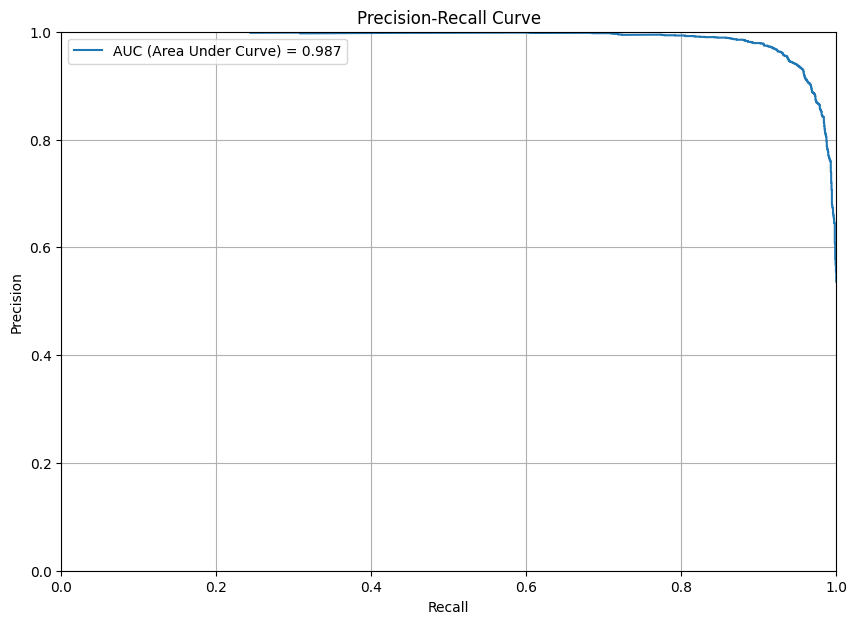

In [12]:
use_raw = False
# regressor = RandomForestClassifier(n_estimators=30,
#                                    random_state=42,
#                                    max_depth=5,
#                                    min_samples_split=5,
#                                    min_samples_leaf=5,
#                                    criterion='entropy',
#                                    class_weight='balanced_subsample', n_jobs=-1)
regressor = HistGradientBoostingClassifier(
    # **{'min_samples_leaf': 20, 'max_leaf_nodes': 100, 'max_iter': 200, 'max_features': 0.4, 'max_bins': 100, 'learning_rate': 0.05, 'l2_regularization': 0.0, 'class_weight': 'balanced'}
# **{'min_samples_leaf': 50, 'max_leaf_nodes': 100, 'max_iter': 200, 'max_features': 0.4, 'max_bins': 80, 'learning_rate': 0.1, 'l2_regularization': 0.0, 'class_weight': 'balanced'}
                                            # )
                                           **{'min_samples_leaf': 50,
                                              'max_leaf_nodes': 31,
                                              'max_iter': 200,
                                              'max_features': 0.8,
                                              'max_bins': 80,
                                              'learning_rate': 0.1,
                                              'l2_regularization': 0.1,
                                              'class_weight': 'balanced'}, random_state=42)
# regressor = MLPClassifier((12, 6, 6, 3), "tanh")
# regressor = LogisticRegression(class_weight='balanced')

def do_SVC(X_train_scaled):
    regressor = SVC(probability=True, class_weight='balanced')
    param_dist = {
        'C': np.logspace(-2, 2, 10),  # e.g., 0.01 to 100
        'kernel': ['rbf', 'sigmoid'],
        'gamma': ['scale', 'auto'] + list(np.logspace(-3, 0, 5)),
    }

    random_search = RandomizedSearchCV(
        estimator=regressor,
        param_distributions=param_dist,
        n_iter=20,   # number of random combinations to try
        scoring='f1',
        cv=5,
        random_state=42,
        n_jobs=-1,
        verbose=2
    )

    random_search.fit(X_train_scaled, y_train)

    # 8. View best parameters and best score
    print("Best parameters:", random_search.best_params_)
    print("Best cross-validation score:", random_search.best_score_)

    best_svc = random_search.best_estimator_
    return best_svc

# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)
# regressor = do_SVC(X_train)
# regressor = SVC(probability=True, class_weight='balanced',
#                 **{'kernel': 'rbf', 'gamma': np.float64(1.0), 'degree': 2, 'C': np.float64(35.93813663804626)})

if use_raw:
    # feature_cols = ['INFO:SpliceAI_DS_AG', 'INFO:SpliceAI_DS_AL', 'INFO:SpliceAI_DS_DG', 'INFO:SpliceAI_DS_DL']
    # feature_cols = ['INFO:SPIP_SPiCE_Prob']
    # feature_cols = ['INFO:Pangolin_Gain', 'INFO:Pangolin_Loss']
    feature_cols = ['INFO:Spliceogen_AccGainP',	'INFO:Spliceogen_AccLossP', 'INFO:Spliceogen_DonGainP', 'INFO:Spliceogen_DonLossP']
    X_train = X_train[feature_cols]
    X_val = X_val[feature_cols]

    y_scores = X_val.abs().max(axis=1)
    X_val['RF_score'] = y_scores
else:
    regressor.fit(X_train, y_train)
    # Predict probabilities
    y_scores = regressor.predict_proba(X_val)[:, 1]
    X_val['RF_score'] = y_scores

# Compute Precision, Recall
precision, recall, thresholds = precision_recall_curve(y_val, y_scores)

# Compute Average Precision (AP)
auPRC = average_precision_score(y_val, y_scores)

# Plot PR curve
plt.figure(figsize=(10, 7))
plt.plot(recall, precision, label=f'AUC (Area Under Curve) = {auPRC:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
ax = plt.gca()
ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 1.0)
plt.legend()
plt.grid(True)
# plt.show()
SAVE = "SEP4_pangolin_nopos_noinfo"
X_val['target'] = target
plt.savefig(f"{SAVE}.png")
X_val.to_csv(f"{SAVE}.tsv", sep='\t')

X_val

In [13]:
print('Training:')
# Compute F1 score (at a specific threshold, e.g., 0.5 for binary classification)
if use_raw:
    y_pred_train = X_train.abs().max(axis=1)
else:
    y_pred_train = regressor.predict(X_train)

print(y_train, y_pred_train)

f1 = f1_score(y_train, y_pred_train)
print(f'F1 Score: {f1:.3f}')
## Accuracy
print(f"Accuracy score (training): {accuracy_score(y_train, y_pred_train):.3f}")
print(f"Balanced accuracy score (training): {balanced_accuracy_score(y_train, y_pred_train):.3f}")

print('Validation:')
y_pred_val = regressor.predict(X_val.drop(columns=['RF_score', 'target']))
f1 = f1_score(y_val, y_pred_val)
print(f'F1 Score: {f1:.3f}')
## Accuracy
print(f"Accuracy score (test): {accuracy_score(y_val, y_pred_val):.3f}")
print(f"Balanced accuracy score (test): {balanced_accuracy_score(y_val, y_pred_val):.3f}")


Training:
23130    0.0
3347     1.0
13492    0.0
12608    1.0
13479    1.0
        ... 
9874     1.0
24937    1.0
4678     0.0
10523    1.0
16912    0.0
Name: ID_SVDBSplice, Length: 15824, dtype: float64 [0. 1. 0. ... 1. 1. 0.]
F1 Score: 0.965
Accuracy score (training): 0.963
Balanced accuracy score (training): 0.964
Validation:
F1 Score: 0.943
Accuracy score (test): 0.941
Balanced accuracy score (test): 0.942


In [14]:
import pickle

with open('all_hgb_model_SEP25.pkl','wb') as f:
    pickle.dump(regressor,f)

In [15]:
import pickle

with open('all_hgb_model_SEP25.pkl', 'rb') as f:
    clf2 = pickle.load(f)

y_scores2 = clf2.predict_proba(X_val.drop(columns=['RF_score', 'target']))[:, 1]

print(y_scores2)

[0.17848258 0.0311198  0.0295579  ... 0.9920968  0.01858562 0.99691918]


In [16]:
import json
c1 = set(X_val.drop(columns=['RF_score', 'target']).columns)
c2 = set(['INFO:GENEINFO_gene_regions_.', "INFO:GENEINFO_gene_regions_('acceptor_canonical',)", "INFO:GENEINFO_gene_regions_('acceptor_exonic',)", "INFO:GENEINFO_gene_regions_('acceptor_region',)", "INFO:GENEINFO_gene_regions_('branchpoint_region',)", "INFO:GENEINFO_gene_regions_('donor_canonical',)", "INFO:GENEINFO_gene_regions_('donor_exonic',)", "INFO:GENEINFO_gene_regions_('donor_region',)", "INFO:AGcheck_Variant_Type_('INDEL',)", "INFO:AGcheck_Variant_Type_('INSDEL',)", "INFO:AGcheck_Variant_Type_('SNV',)", 'INFO:AGcheck_AG_Created', 'INFO:AGcheck_AG_Lost', 'INFO:AGcheck_GT_Created', 'INFO:AGcheck_GT_Lost', 'INFO:Branchpointer_Prob', 'INFO:Branchpointer_U2_Binding_Energy', 'INFO:Branchpointer_max_Prob', 'INFO:Branchpointer_max_U2_Binding_Energy', 'INFO:Branchpointer_options', 'INFO:ESE_A1_Hazeem_alt', 'INFO:ESE_A1_Hazeem_diff', 'INFO:ESE_A1_Hazeem_july_alt', 'INFO:ESE_A1_Hazeem_july_diff', 'INFO:ESE_A1_neuBG_alt', 'INFO:ESE_A1_neuBG_diff', 'INFO:ESE_A1_winBG_alt', 'INFO:ESE_A1_winBG_diff', 'INFO:ESE_SRSF1_alt', 'INFO:ESE_SRSF1_diff', 'INFO:ESE_SRSF1_igM_alt', 'INFO:ESE_SRSF1_igM_diff', 'INFO:ESE_SRSF2_alt', 'INFO:ESE_SRSF2_diff', 'INFO:ESE_SRSF5_alt', 'INFO:ESE_SRSF5_diff', 'INFO:ESE_SRSF6_alt', 'INFO:ESE_SRSF6_diff', 'INFO:MMSplice_alt_acceptor', 'INFO:MMSplice_alt_acceptor_intron', 'INFO:MMSplice_alt_donor', 'INFO:MMSplice_alt_donor_intron', 'INFO:MMSplice_alt_exon', 'INFO:MMSplice_delta_logit_PSI', 'INFO:MMSplice_pathogenicity', 'INFO:MMSplice_ref_acceptor', 'INFO:MMSplice_ref_acceptor_intron', 'INFO:MMSplice_ref_donor', 'INFO:MMSplice_ref_donor_intron', 'INFO:MMSplice_ref_exon', 'INFO:Pangolin_Gain', 'INFO:Pangolin_Loss', 'INFO:SPIP_Range_Max', 'INFO:SPIP_Range_Min', 'INFO:SPIP_Score', 'INFO:SPIP_SPiCE_Prob', 'INFO:SpliceAI_DP_AG', 'INFO:SpliceAI_DP_AL', 'INFO:SpliceAI_DP_DG', 'INFO:SpliceAI_DP_DL', 'INFO:SpliceAI_DS_AG', 'INFO:SpliceAI_DS_AG_ALT', 'INFO:SpliceAI_DS_AL', 'INFO:SpliceAI_DS_AL_ALT', 'INFO:SpliceAI_DS_DG', 'INFO:SpliceAI_DS_DG_ALT', 'INFO:SpliceAI_DS_DL', 'INFO:SpliceAI_DS_DL_ALT', 'INFO:Spliceogen_AccGainP', 'INFO:Spliceogen_AccLossP', 'INFO:Spliceogen_DonGainP', 'INFO:Spliceogen_DonLossP', 'INFO:Spliceogen_ESEmaxAlt', 'INFO:Spliceogen_ESEmaxRef', 'INFO:Spliceogen_ESSminAlt', 'INFO:Spliceogen_ESSminRef', 'INFO:Spliceogen_mesAccAlt', 'INFO:Spliceogen_mesAccRef', 'INFO:Spliceogen_mesDonAlt', 'INFO:Spliceogen_mesDonRef', 'INFO:U12_Intron_Type', 'INFO:U12_score', 'INFO:GENEINFO_is_intronic', 'INFO:GENEINFO_strand_minus', 'INFO:GENEINFO_strand_plus'])

print(len(c1))
print(len(c2))

print(c1-c2)
print(c2-c1)

with open('columns.json', 'w') as f:
    json.dump(list(X_val.drop(columns=['RF_score', 'target']).columns), f)

81
85
set()
{'INFO:SpliceAI_DP_DL', 'INFO:SpliceAI_DP_AL', 'INFO:SpliceAI_DP_DG', 'INFO:SpliceAI_DP_AG'}


auROC:  0.9857854994802362
auPRC:  0.989873035495936


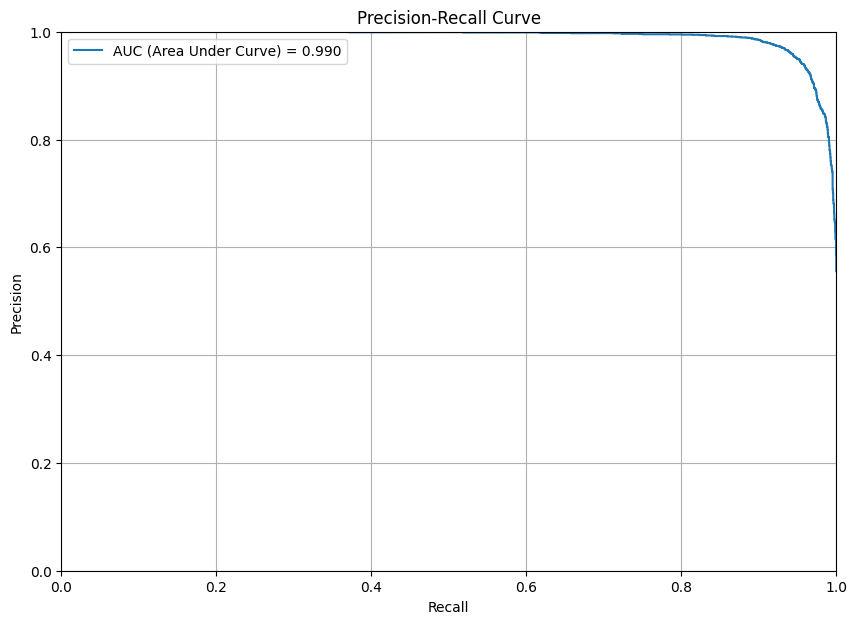

In [17]:
from sklearn.metrics import roc_auc_score, average_precision_score
y_scores = clf2.predict_proba(X_test)[:, 1]

auROC = roc_auc_score(y_test, y_scores)
print("auROC: ", auROC)

auPRC = average_precision_score(y_test, y_scores)
print("auPRC: ", auPRC)

precision, recall, thresholds = precision_recall_curve(y_test, y_scores)
# Plot PR curve
plt.figure(figsize=(10, 7))
plt.plot(recall, precision, label=f'AUC (Area Under Curve) = {auPRC:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
ax = plt.gca()
ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 1.0)
plt.legend()
plt.grid(True)

In [ ]:
from sklearn.metrics import classification_report
from sklearn.model_selection import ShuffleSplit
X_train, X_test, y_train, y_test = train_test_split(
    features, target, 
    test_size=0.2, 
    random_state=42,
    shuffle=True
)

# Define the parameter distribution for RandomizedSearchCV
param_dist = {
    'class_weight': ['balanced'],
    'max_bins': [40, 60, 80, 100],
    'max_iter': [200],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_features': [0.3, 0.4, 0.6, 0.8, 1.0],
    'max_leaf_nodes': [31, 50, 100],
    'min_samples_leaf': [20, 50, 100],
    'l2_regularization': [0.0, 0.05, 0.25, 1],
}

# Initialize the HistGradientBoostingClassifier
hgb = HistGradientBoostingClassifier(random_state=42)

# Set up RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=hgb,
    param_distributions=param_dist,
    n_iter=20,           # number of random parameter settings to try
    scoring='f1',         # evaluation metric
    cv=ShuffleSplit(n_splits=5, test_size=0.2, random_state=0),      # 5-fold cross-validation
    random_state=42,
    n_jobs=-1,           # use all available cores
    verbose=1
)

# Perform the randomized search on training data
random_search.fit(X_train, y_train)

# Output the best parameters and best cross-validation score
print("Best Parameters:", random_search.best_params_)
print("Best CV Score:", random_search.best_score_)

# Evaluate the best estimator on the test set
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)
print("Test Set Classification Report:")
print(classification_report(y_test, y_pred, digits=4))